In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import OrdinalEncoder
import random
random.seed(118)



In [2]:
path="/Users/mattgonzales/Downloads/Labeled Turnips - turnip_weekly_clean.csv"

In [4]:
turnip=pd.read_csv(path)
turnip = turnip.dropna()


In [11]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(turnip['Label'])


In [13]:
price_cols = turnip.columns[1:-1]  # all price columns
X = turnip[price_cols] 

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [70]:
from xgboost import XGBClassifier


In [112]:
model = XGBClassifier(
    num_class=len(le.classes_), 
    eval_metric='mlogloss',
    objective='multi:softmax',
    max_depth=3,
    learning_rate=0.02,
    n_estimators=100,
    random_state=42
)
model.fit(X_train, y_train)
preds = model.predict(X_test)

In [113]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, preds)
print("The accuracy for XGBoost is:", accuracy)

The accuracy for XGBoost is: 0.9047619047619048


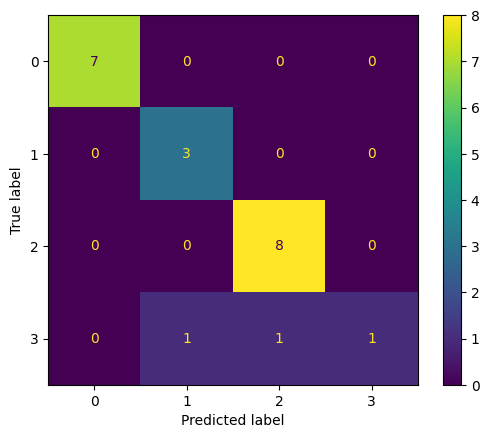

In [114]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()